In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain
from tqdm import tqdm

file_path = "/work/hdd/bbjs/shared/powsm/s2t1/dump/raw/train_fixed/text"
lang_regex = re.compile(r"<([a-z]{3})>")
phone_regex = re.compile(r"/([^/ \n]+)/")

data = []

with open(file_path) as f:
    for line in tqdm(f):
        line = line.strip()
        if not line:
            continue
        key, line = line.split(" ", 1)
        if not key.endswith("_pr"):
            continue
        lang_match = lang_regex.search(line)
        lang = lang_match.group(1) if lang_match else "unknown"
        phones = phone_regex.findall(line)
        data.append({"language": lang, "phones": phones, "seq_len": len(phones)})

df = pd.DataFrame(data)

all_phones = list(chain.from_iterable(df["phones"]))
phone_counts = Counter(all_phones)
phone_stats = pd.DataFrame(
    phone_counts.items(), columns=["phone", "count"]
).sort_values(by="count", ascending=False)

33099128it [01:49, 301664.14it/s]


/tmp/ipykernel_3984477/439507692.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="language", palette="viridis")
/tmp/ipykernel_3984477/439507692.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20, x="count", y="phone", palette="magma")
/tmp/ipykernel_3984477/439507692.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_20, x="count", y="phone", palette="rocket")


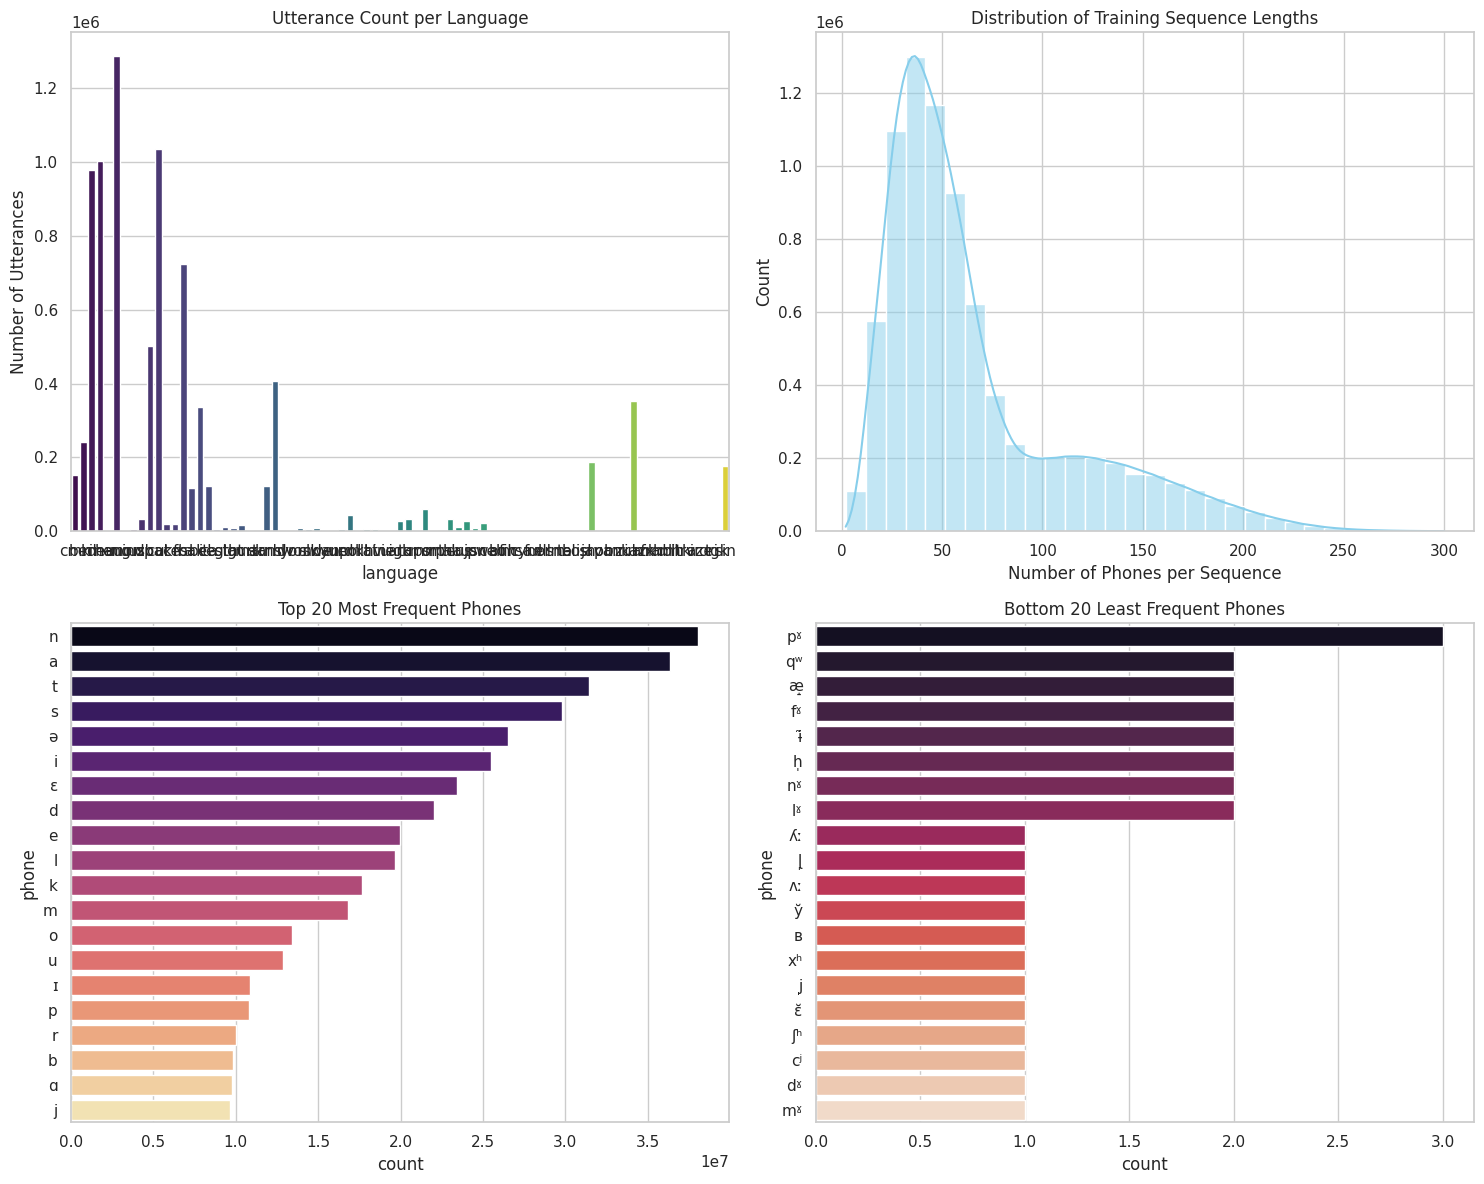

In [ ]:
# --- VISUALIZATIONS ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# Plot 1: Language vs Count
plt.subplot(2, 2, 1)
sns.countplot(data=df, x="language", palette="viridis")
plt.title("Utterance Count per Language")
plt.ylabel("Number of Utterances")

# Plot 2: Histogram of Sequence Lengths
plt.subplot(2, 2, 2)
sns.histplot(df["seq_len"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Training Sequence Lengths")
plt.xlabel("Number of Phones per Sequence")

# Plot 3: Top 20 Phones
plt.subplot(2, 2, 3)
top_20 = phone_stats.head(20)
sns.barplot(data=top_20, x="count", y="phone", palette="magma")
plt.title("Top 20 Most Frequent Phones")

# Plot 4: Bottom 20 Phones
plt.subplot(2, 2, 4)
bottom_20 = phone_stats.tail(20)
sns.barplot(data=bottom_20, x="count", y="phone", palette="rocket")
plt.title("Bottom 20 Least Frequent Phones")

plt.tight_layout()
plt.show()

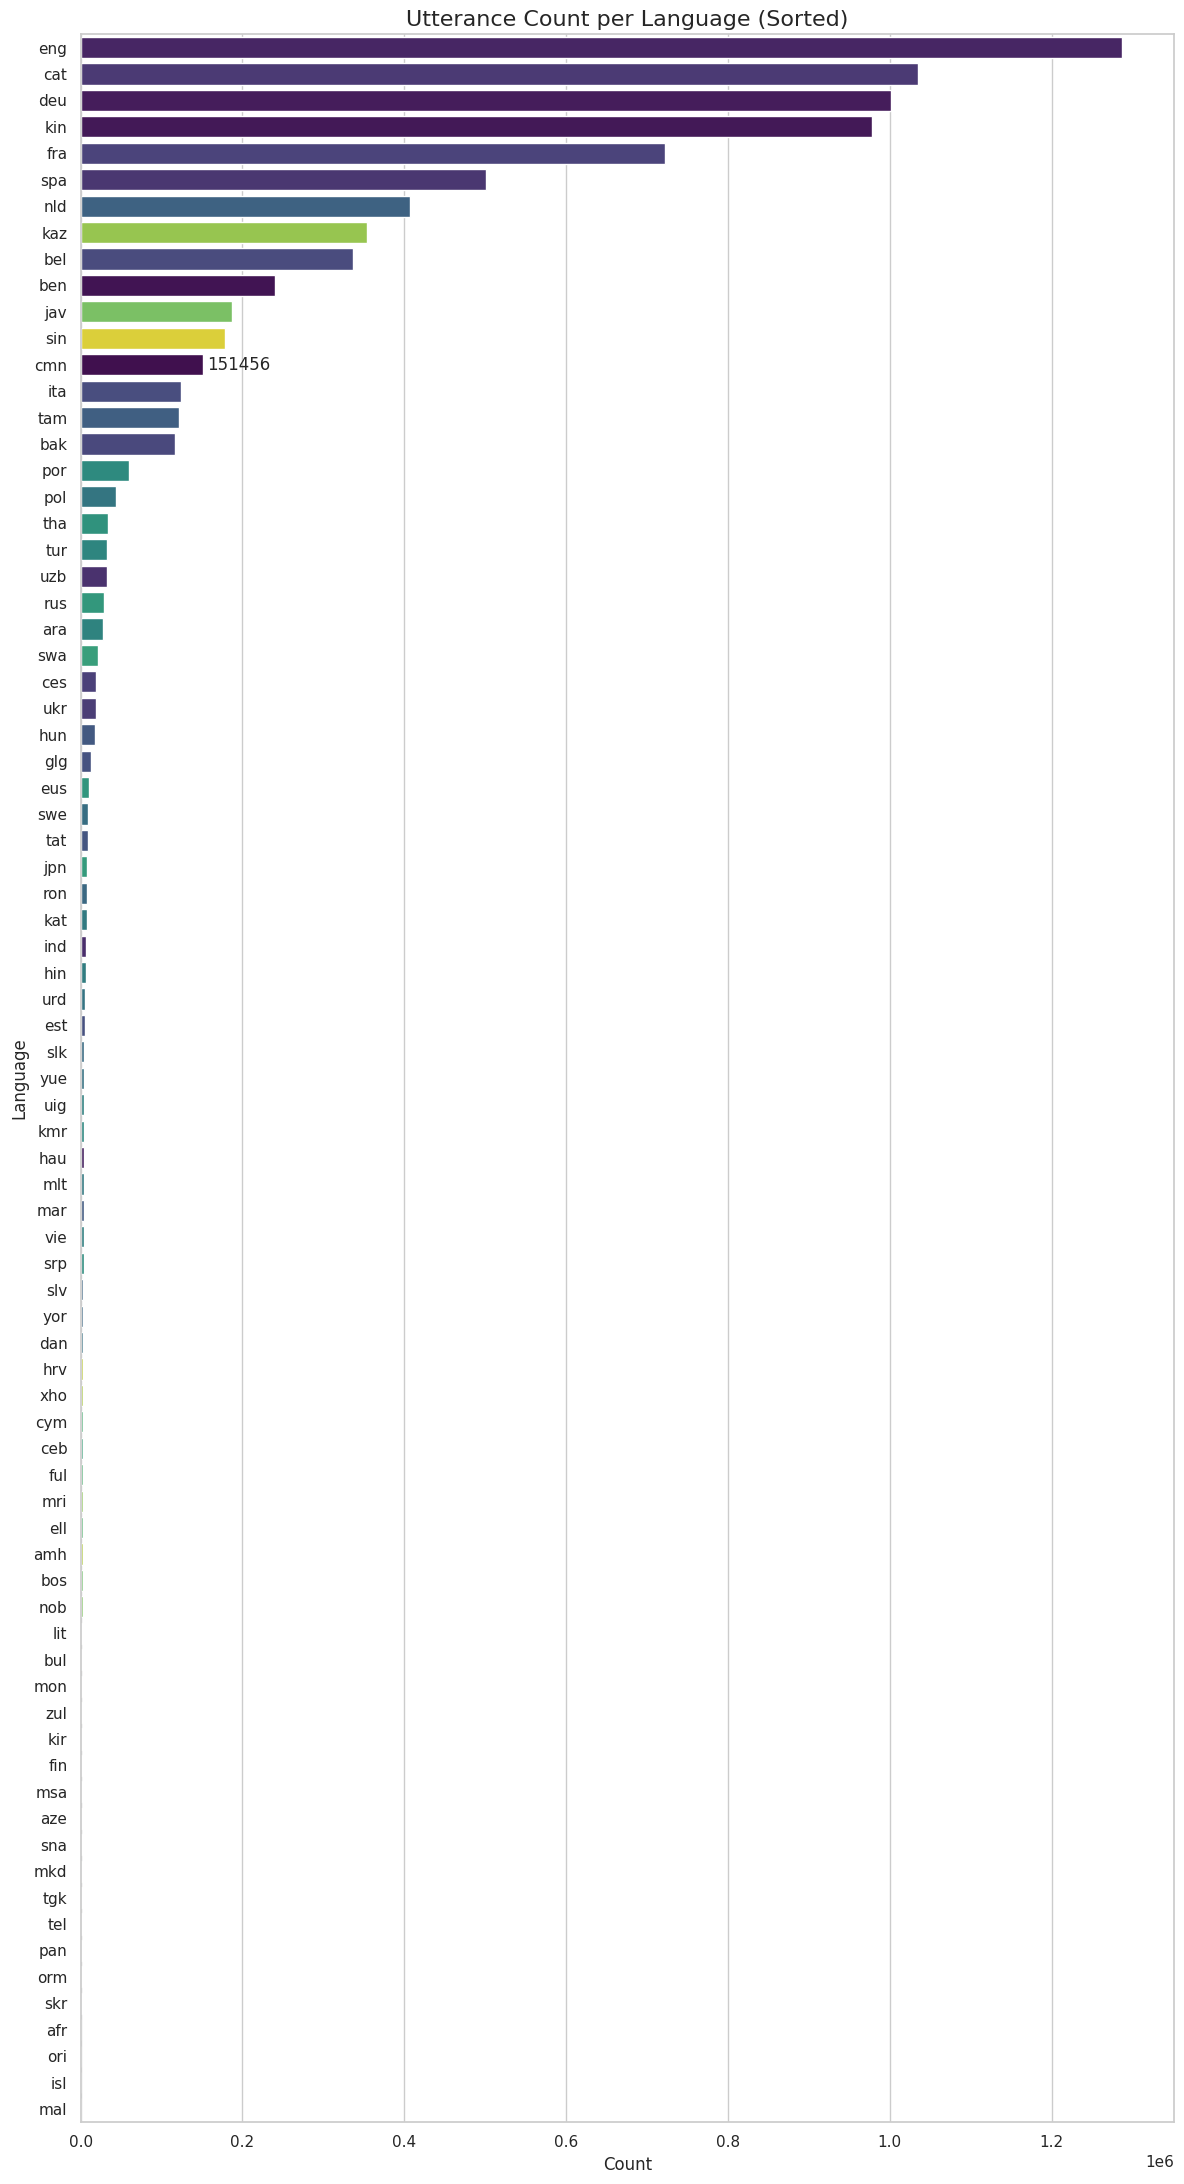

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the order so they are sorted by count
lang_order = df["language"].value_counts().index

# 2. Set a large height (22 inches) to spread out the 88 languages
plt.figure(figsize=(12, 22))
sns.set_theme(style="whitegrid")

# 3. Use y="language" for a horizontal plot and apply the order
ax = sns.countplot(
    data=df,
    y="language",
    order=lang_order,
    palette="viridis",
    hue="language",
    legend=False,
)

# 4. Final formatting
plt.title("Utterance Count per Language (Sorted)", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Language")

# Add text labels on the bars so you don't have to guess the values
ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

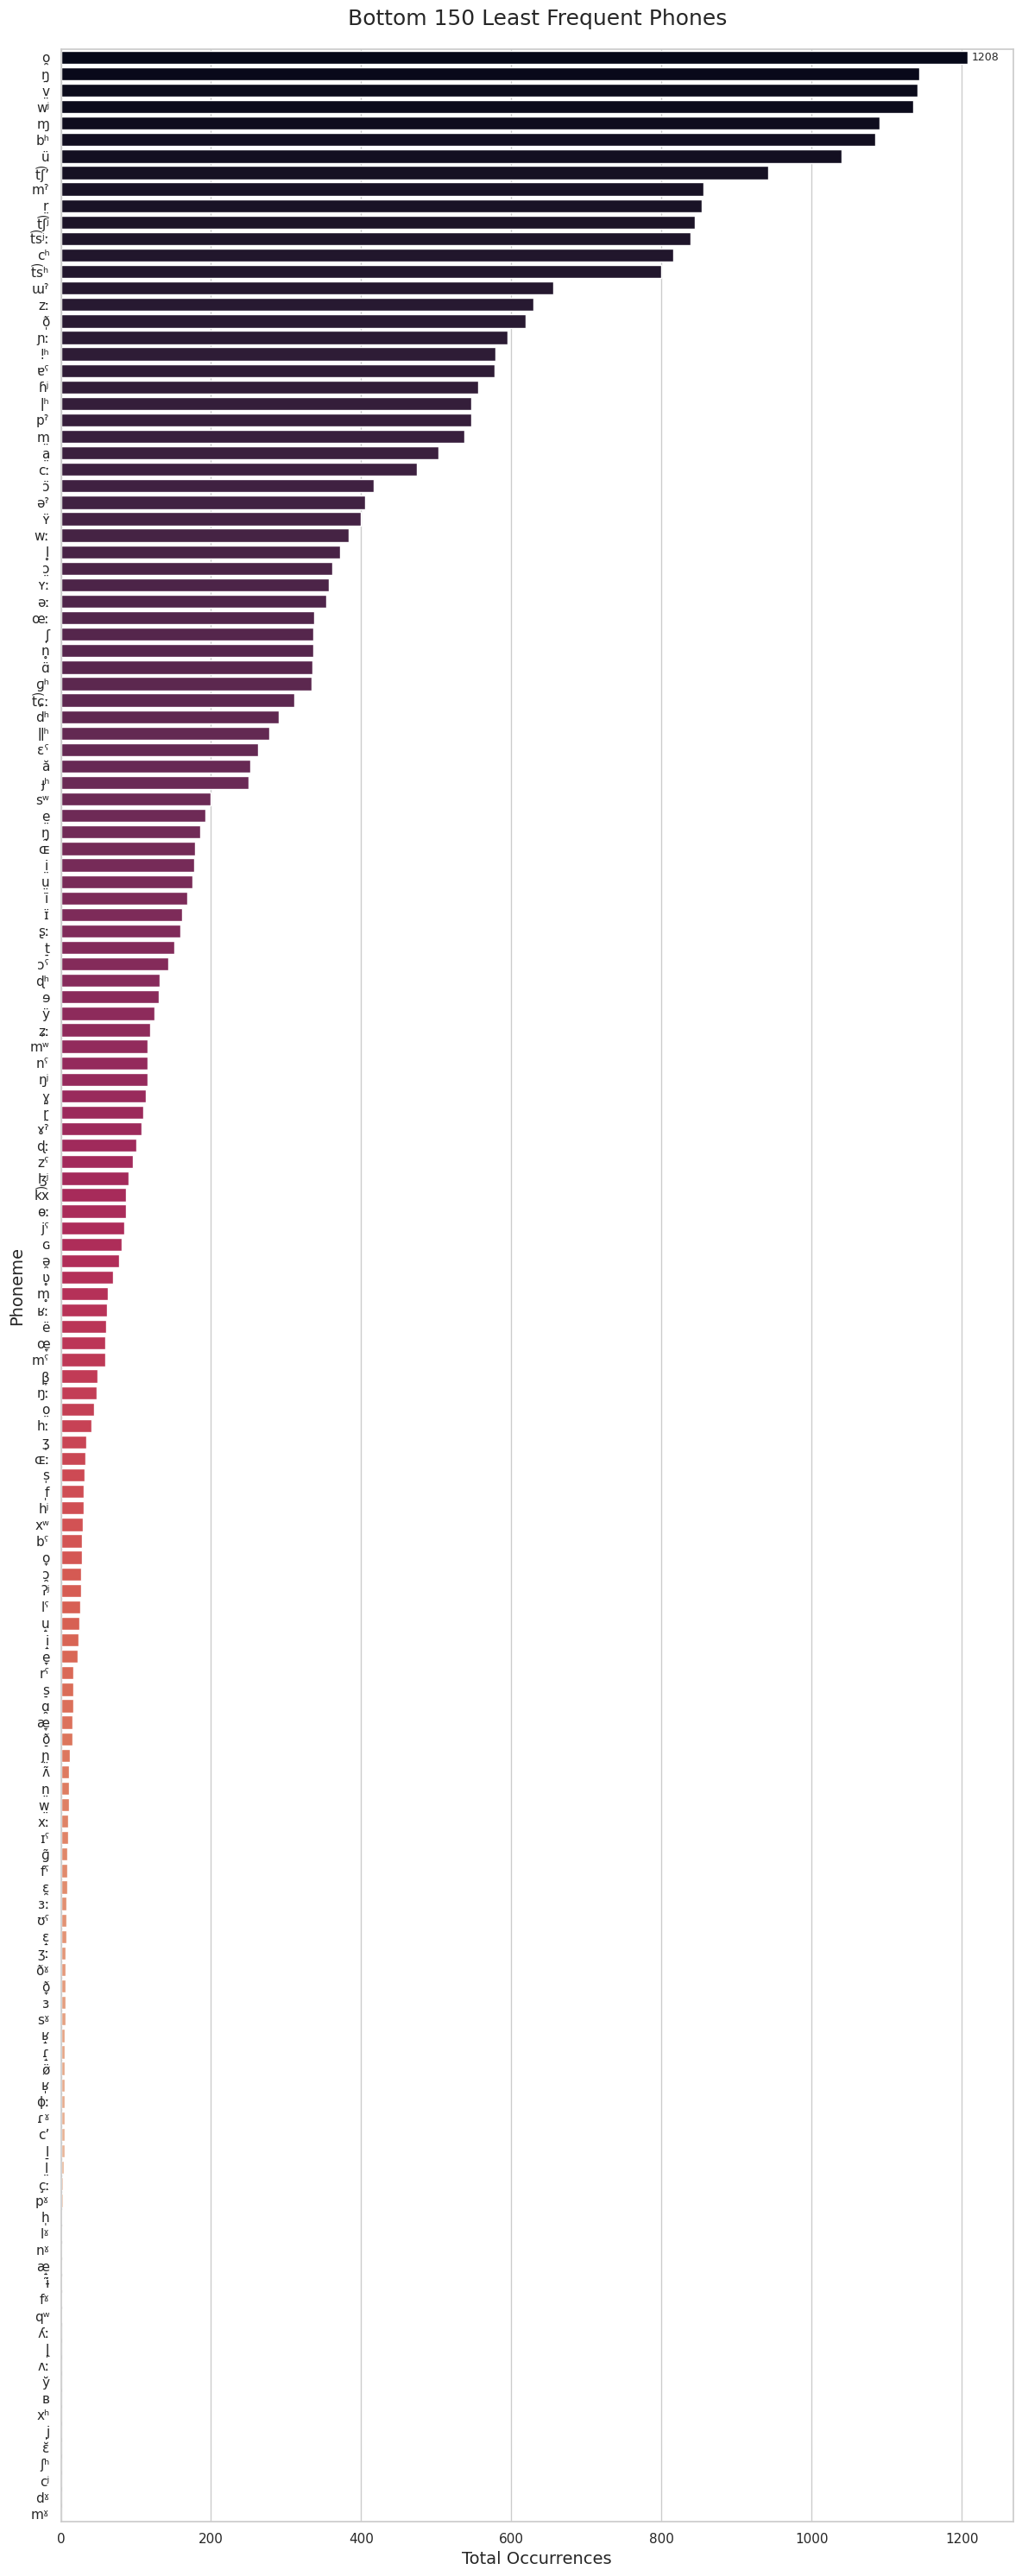

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the bottom 150 phones (least frequent)
# We take the tail and sort it so the absolute rarest is at the bottom or top
bottom_150 = phone_stats.tail(150).sort_values(by="count", ascending=False)

# 2. Set a very tall figure height for 150 rows
plt.figure(figsize=(12, 30))
sns.set_theme(style="whitegrid")

# 3. Create the horizontal bar chart
ax = sns.barplot(
    data=bottom_150, x="count", y="phone", palette="rocket", hue="phone", legend=False
)

# 4. Add labels and title
plt.title("Bottom 150 Least Frequent Phones", fontsize=18, pad=20)
plt.xlabel("Total Occurrences", fontsize=14)
plt.ylabel("Phoneme", fontsize=14)

# 5. Add exact count labels to the end of each bar
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

pth = "/work/nvme/bbjs/sbharadwaj/powsm/xeuspr/exp/cache/lengths_pr.npy"
lengths = np.load(pth, allow_pickle=True)
lengths